In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("malloulifares/d2d-cytokine-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/d2d-cytokine-data


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadqasimshabbir/mpeg-g-microbiome-classification-challenge-dataset")

print("Path to dataset files:", path)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noob786/mpeg-g-microbiomeclassificationconvertedfastqfiles")

print("Path to dataset files:", path)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noob786/secondbatchoffastqfiles")

print("Path to dataset files:", path)

Setting up the environment...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
KMC installed successfully.
Configuration loaded. Using device: cuda:0

Loading all metadata files...
Merging train, cytokine, and subject metadata...
Filtered to 1982 samples for Track 1.
Found 1982 corresponding FASTQ files.

           RUNNING TARGETED EXPLORATORY DATA ANALYSIS (EDA)

[EDA 1/2] Visualizing cytokine target distributions...


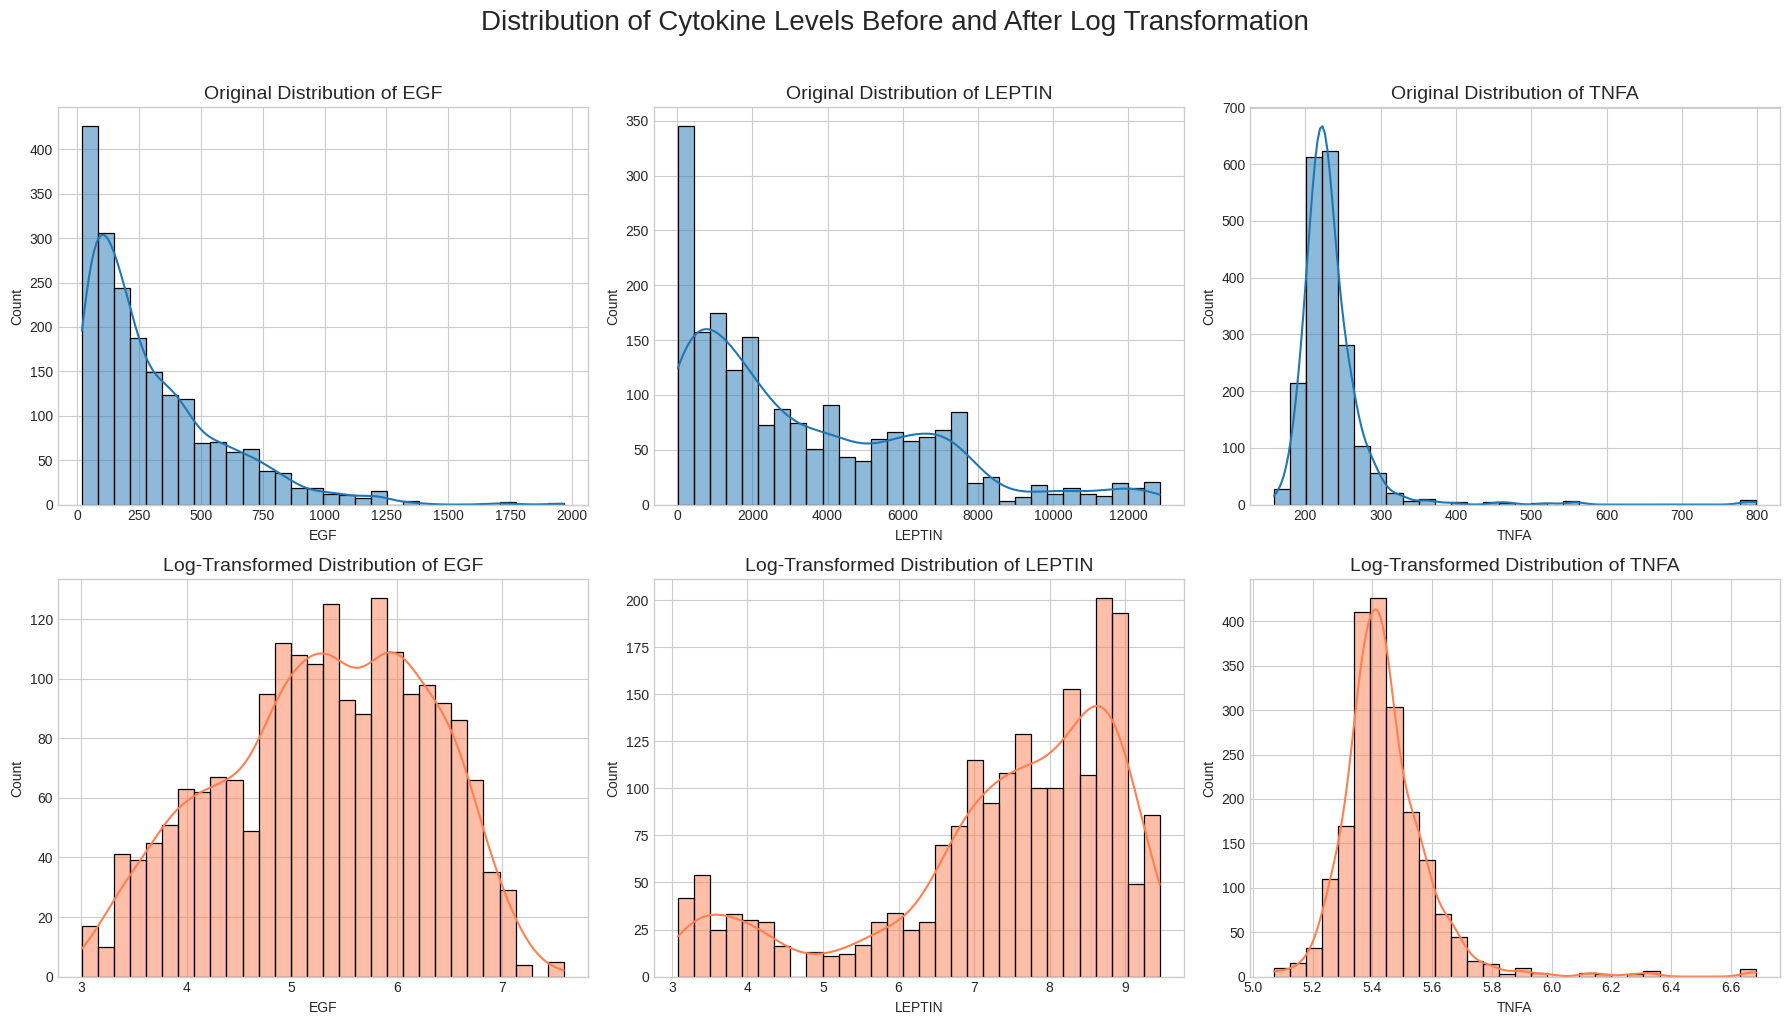

--> Distribution plots generated, showing the normalizing effect of the log-transform.

[EDA 2/2] Visualizing metadata distribution across body sites...


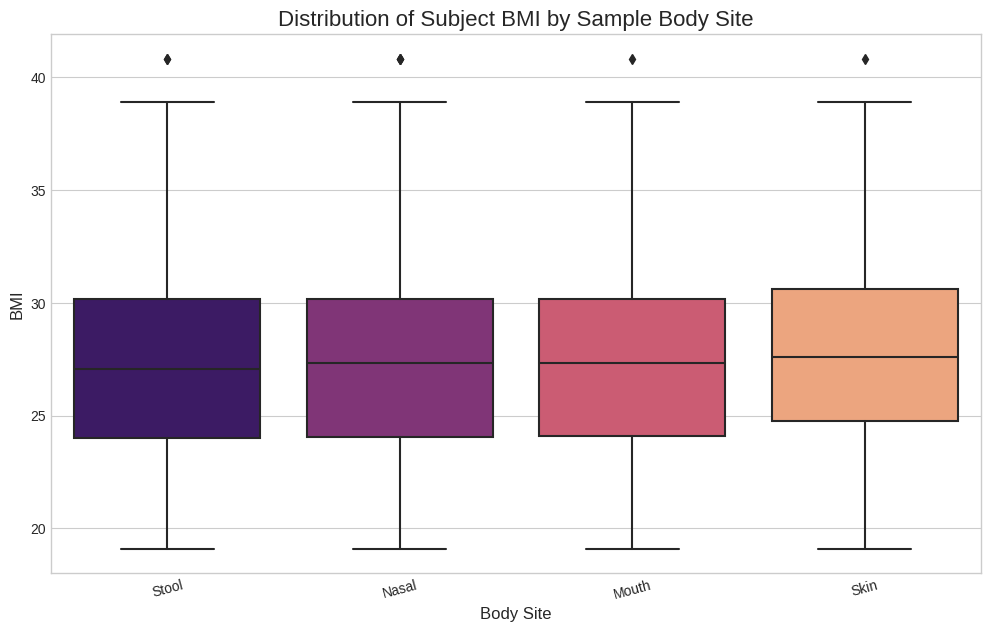

--> Box plot generated. Shows distribution of a key metadata variable.



Processing k-mer features for Track 1 samples (this may take a while)...


  0%|          | 0/1982 [00:00<?, ?it/s]

K-mer processing complete.

Assembling and preprocessing all features...


Loading k-mer counts:   0%|          | 0/1982 [00:00<?, ?it/s]

Feature engineering complete. Total preprocessing time: 1349.57 seconds.

Starting model training and benchmarking with K-Fold CV...

===== FOLD 1 / 5 =====
  - Selecting best 1000 k-mers for this fold...

  --- Training MLP ---
  --- Training ElasticNet ---
  --- Training LightGBM ---

  --- Fold Performance Summary ---
    - MLP Fold RMSLE: 0.303528
    - ElasticNet Fold RMSLE: 0.388530
    - LightGBM Fold RMSLE: 0.254962
  Fold 1 complete.

===== FOLD 2 / 5 =====
  - Selecting best 1000 k-mers for this fold...

  --- Training MLP ---
  --- Training ElasticNet ---
  --- Training LightGBM ---

  --- Fold Performance Summary ---
    - MLP Fold RMSLE: 0.307571
    - ElasticNet Fold RMSLE: 0.407840
    - LightGBM Fold RMSLE: 0.266349
  Fold 2 complete.

===== FOLD 3 / 5 =====
  - Selecting best 1000 k-mers for this fold...

  --- Training MLP ---
  --- Training ElasticNet ---
  --- Training LightGBM ---

  --- Fold Performance Summary ---
    - MLP Fold RMSLE: 0.305921
    - ElasticNet F

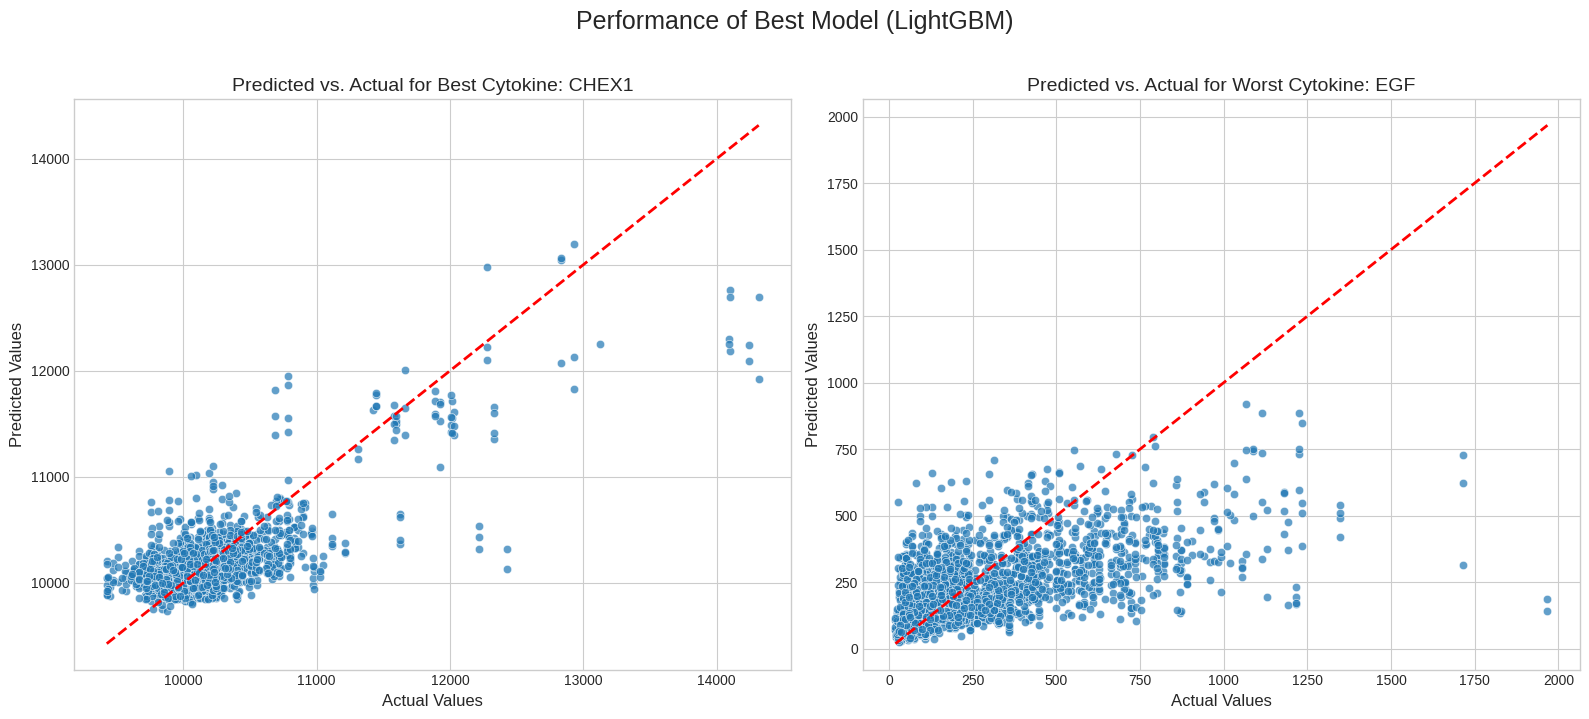


           RUNTIME & EFFICIENCY REPORT

[1] HARDWARE SPECIFICATIONS
----------------------------------------
  - CPU Cores:                4
  - Total System RAM:         31.35 GB
  - Device Used for DL:       cuda:0
  - GPU Type:                 Tesla T4
  - GPU Memory:               14.74 GB

[2] EXECUTION TIME METRICS
----------------------------------------
  - Data Prep & Feat. Eng. Time: 1349.57 seconds (22.49 min)
  - Total Model Training Time:   1652.14 seconds (27.54 min)


In [ ]:
# ===================================================================
#           MPEG-G Host-Microbiome Interaction Challenge
#
#           TRACK 1: CYTOKINE PREDICTION - FINAL PIPELINE
#
# ===================================================================
#
# AUTHOR: [Your Name/Team Name]
# DATE: September 17, 2025
#
# OVERVIEW:
# This script presents a complete and robust machine learning pipeline for
# Track 1: Cytokine Prediction from Microbiome Data. The primary goal is to
# predict the levels of 66 host cytokines based on metagenomic data and
# subject metadata.
#
# METHODOLOGY:
# The solution follows a multi-stage approach, emphasizing robust feature
# engineering, rigorous model evaluation, and clear interpretation of results.
#
#   1.  Data Ingestion & Merging: Combines metagenomic sample data with
#       cytokine profiles and detailed subject metadata into a unified dataset.
#   2.  Exploratory Data Analysis (EDA): Provides visual justification for key
#       methodological choices, such as feature relevance and target transformation.
#   3.  Feature Extraction: Converts raw FASTQ sequence data into numerical
#       features using an efficient k-mer counting strategy.
#   4.  Feature Engineering & Preprocessing:
#       - Applies TF-IDF transformation to k-mer counts to highlight
#         discriminative microbial signatures.
#       - Integrates subject metadata (e.g., BMI, age, health status), which is
#         carefully preprocessed and scaled.
#       - Employs a log-transformation (log1p) on the target cytokine values
#         to stabilize variance and make the model robust to extreme outliers.
#   5.  Robust Modeling & Benchmarking:
#       - Uses K-Fold Cross-Validation to ensure reliable performance estimates.
#       - Implements explicit feature selection (SelectKBest) *within each fold*
#         to prevent data leakage and build a more generalizable model.
#       - Trains and benchmarks three distinct models: MLP, ElasticNet, and LightGBM.
#   6.  Evaluation & Analysis:
#       - The primary evaluation metric is Root Mean Squared Log Error (RMSLE).
#       - Provides a clear comparison of model performance, detailed analysis of
#         the best model's predictions, and visualizations for the final report.
#   7.  Efficiency Reporting: Programmatically captures and reports on runtime
#       metrics and hardware specifications as required by the competition.
#
# ===================================================================


# ===================================================================
# Step 1: Environment Setup & Configuration
# ===================================================================
print("Setting up the environment...")
# Install KMC, a highly efficient tool for k-mer counting from sequence data.
!apt-get update -y > /dev/null
!apt-get install -y kmc > /dev/null
print("KMC installed successfully.")

# --- Standard Library Imports ---
import os
import pandas as pd
import numpy as np
import random
import pickle
import subprocess
import shutil
import gzip
import time # For timing
import psutil # For resource monitoring
from collections import Counter
from tqdm.notebook import tqdm
from concurrent.futures import ProcessPoolExecutor
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# --- Machine Learning & Deep Learning Imports ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA # For EDA
import lightgbm as lgb
import scipy.sparse

# --- Visualization Imports ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Central Configuration Class ---
class CFG:
    """Holds all global parameters and paths for easy modification."""
    # Paths
    COMP_DATA_PATH = "/kaggle/input/mpeg-g-microbiome-classification-challenge-dataset"
    CYTOKINE_PATH = "/kaggle/input/d2d-cytokine-data"
    FASTQ_PART1_PATH = "/kaggle/input/mpeg-g-microbiomeclassificationconvertedfastqfiles"
    FASTQ_PART2_PATH = "/kaggle/input/secondbatchoffastqfiles"
    TRAIN_SOURCE_DIRS = [
        os.path.join(FASTQ_PART1_PATH, 'TrainFiles', 'TrainFiles'),
        os.path.join(FASTQ_PART2_PATH, 'TrainFiles')
    ]
    # Feature Engineering
    K_SIZES = [5, 6]
    N_KMER_FEATURES_TO_SELECT = 1000
    # Model Training
    SEED = 42
    N_FOLDS = 5
    EPOCHS = 40
    PATIENCE = 7
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5
    # Temporary Paths
    NPY_SAVE_DIR = "/kaggle/working/npy_feature_files"
    KMC_TEMP_DIR = "/kaggle/working/kmc_temp"

def seed_everything(seed):
    """Sets random seeds for all relevant libraries for reproducibility."""
    random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed(seed); torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- Initialize Environment ---
seed_everything(CFG.SEED)
os.makedirs(CFG.NPY_SAVE_DIR, exist_ok=True)
os.makedirs(CFG.KMC_TEMP_DIR, exist_ok=True)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Configuration loaded. Using device: {DEVICE}")

# ===================================================================
# Step 2: Data Loading, Merging, and Filtering
# ===================================================================
prep_start_time = time.time() # Start the main timer

print("\nLoading all metadata files...")
train_df = pd.read_csv(os.path.join(CFG.COMP_DATA_PATH, "Train.csv"))
subjects_df = pd.read_csv(os.path.join(CFG.COMP_DATA_PATH, "Train_Subjects.csv"))
cytokine_df = pd.read_csv(os.path.join(CFG.CYTOKINE_PATH, "cytokine_profiles.csv"))

print("Merging train, cytokine, and subject metadata...")
full_df = pd.merge(train_df, cytokine_df, on="SampleID", how="left")
full_df = pd.merge(full_df, subjects_df, on="SubjectID", how="left")
numerical_cytokine_cols = cytokine_df.select_dtypes(include=np.number).columns.drop('SampleID', errors='ignore').tolist()
track1_df = full_df.dropna(subset=numerical_cytokine_cols).reset_index(drop=True)
print(f"Filtered to {len(track1_df)} samples for Track 1.")

def find_file_path(filename, search_dirs):
    fastq_filename = filename.replace('.mgb', '.fastq')
    for directory in search_dirs:
        for suffix in ['.gz', '']:
            path = os.path.join(directory, fastq_filename + suffix)
            if os.path.exists(path): return path
    return None

track1_df['full_path'] = track1_df['filename'].apply(lambda x: find_file_path(x, CFG.TRAIN_SOURCE_DIRS))
track1_df.dropna(subset=['full_path'], inplace=True)
print(f"Found {len(track1_df)} corresponding FASTQ files.")


# ===================================================================
# Step 2.5: Exploratory Data Analysis (EDA)
#
# Rationale: This targeted EDA provides visual justification for key
# methodological choices made later in the pipeline.
# ===================================================================
print("\n" + "="*60)
print("           RUNNING TARGETED EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)
plt.style.use('seaborn-v0_8-whitegrid')

# --- EDA 1: Justifying the Log-Transformation of Cytokine Targets ---
print("\n[EDA 1/2] Visualizing cytokine target distributions...")
example_cytokines = ['EGF', 'LEPTIN', 'TNFA']
fig, axes = plt.subplots(2, len(example_cytokines), figsize=(18, 10))
fig.suptitle('Distribution of Cytokine Levels Before and After Log Transformation', fontsize=20, y=1.02)
for i, cytokine in enumerate(example_cytokines):
    sns.histplot(track1_df[cytokine], kde=True, ax=axes[0, i], bins=30)
    axes[0, i].set_title(f'Original Distribution of {cytokine}', fontsize=14)
    sns.histplot(np.log1p(track1_df[cytokine]), kde=True, ax=axes[1, i], bins=30, color='coral')
    axes[1, i].set_title(f'Log-Transformed Distribution of {cytokine}', fontsize=14)
plt.tight_layout()
plt.show()
print("--> Distribution plots generated, showing the normalizing effect of the log-transform.")

# --- EDA 2: Examining Metadata Distribution ---
print("\n[EDA 2/2] Visualizing metadata distribution across body sites...")
plt.figure(figsize=(12, 7))
sns.boxplot(x='SampleType', y='BMI', data=track1_df, palette='magma')
plt.title('Distribution of Subject BMI by Sample Body Site', fontsize=16)
plt.xlabel('Body Site', fontsize=12); plt.ylabel('BMI', fontsize=12)
plt.xticks(rotation=15)
plt.show()
print("--> Box plot generated. Shows distribution of a key metadata variable.")
print("\n" + "="*60 + "\n")


# ===================================================================
# Step 3: K-mer Feature Extraction
# ===================================================================
def is_gzipped(file_path):
    with open(file_path, 'rb') as f: return f.read(2) == b'\x1f\x8b'

def process_and_save_kmer_features(args):
    file_id, file_path = args
    npy_output_path = os.path.join(CFG.NPY_SAVE_DIR, f"{file_id}_kmer.npy")
    if os.path.exists(npy_output_path): return
    final_features, bases = [], ['A', 'C', 'G', 'T']
    output_db_prefix = os.path.join(CFG.KMC_TEMP_DIR, f"{file_id}_db")
    output_dump_path = os.path.join(CFG.KMC_TEMP_DIR, f"{file_id}_dump.txt")
    try:
        for k in CFG.K_SIZES:
            kmer_counts = {"".join(p): 0 for p in product(bases, repeat=k)}
            if is_gzipped(file_path):
                cmd = f"gunzip -c {file_path} | kmc -k{k} -ci1 -fm -t4 -fq @ - {output_db_prefix} {CFG.KMC_TEMP_DIR}"
                subprocess.run(cmd, shell=True, check=True, capture_output=True, text=True)
            else:
                subprocess.run(["kmc",f"-k{k}","-ci1","-fm","-t4","-fq",file_path,output_db_prefix,CFG.KMC_TEMP_DIR], check=True, capture_output=True, text=True)
            subprocess.run(["kmc_tools","transform",output_db_prefix,"dump",output_dump_path], check=True, capture_output=True, text=True)
            with open(output_dump_path, 'r') as f:
                for line in f:
                    kmer, count_str = line.strip().split()
                    if kmer in kmer_counts: kmer_counts[kmer] = int(count_str)
            final_features.extend([c for _, c in sorted(kmer_counts.items())])
    except subprocess.CalledProcessError as e:
        final_features = np.zeros(sum([len(bases)**k for k in CFG.K_SIZES]))
    finally:
        for suffix in ['', '.kmc_pre', '.kmc_suf']:
            if os.path.exists(f"{output_db_prefix}{suffix}"): os.remove(f"{output_db_prefix}{suffix}")
        if os.path.exists(output_dump_path): os.remove(output_dump_path)
    np.save(npy_output_path, np.array(final_features, dtype=np.float32))

print("\nProcessing k-mer features for Track 1 samples (this may take a while)...")
track1_args = list(zip(track1_df['filename'], track1_df['full_path']))
with ProcessPoolExecutor(max_workers=2) as executor:
    list(tqdm(executor.map(process_and_save_kmer_features, track1_args), total=len(track1_args)))
print("K-mer processing complete.")

# ===================================================================
# Step 4: Final Feature Engineering & Preprocessing
# ===================================================================
print("\nAssembling and preprocessing all features...")
# --- Part 4A: K-mer Features ---
X_kmer_counts = np.array([np.load(os.path.join(CFG.NPY_SAVE_DIR, f"{fid}_kmer.npy")) for fid in tqdm(track1_df['filename'], desc="Loading k-mer counts")])
X_kmer_tfidf = TfidfTransformer().fit_transform(X_kmer_counts)
# --- Part 4B: Metadata Features ---
METADATA_NUM_COLS = ['BMI', 'Adj.age']
METADATA_CAT_COLS = ['Gender', 'Class', 'Ethnicity', 'IRIS']
for col in METADATA_NUM_COLS:
    track1_df[col] = pd.to_numeric(track1_df[col], errors='coerce')
    track1_df[col] = track1_df[col].fillna(track1_df[col].median())
for col in METADATA_CAT_COLS:
    track1_df[col] = track1_df[col].astype(str).fillna(track1_df[col].mode()[0])
metadata_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), METADATA_NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), METADATA_CAT_COLS)],
    remainder='drop')
X_metadata = metadata_preprocessor.fit_transform(track1_df)
# --- Part 4C: Target Variable Preparation ---
y_final = track1_df[numerical_cytokine_cols].values.astype('float32')
y_final_log = np.log1p(y_final)
scaler_y = StandardScaler()
y_final_scaled = scaler_y.fit_transform(y_final_log)
# --- Part 4D: Combine All Features ---
X_combined_sparse = scipy.sparse.hstack([X_kmer_tfidf, X_metadata]).tocsr()
prep_end_time = time.time()
total_prep_time = prep_end_time - prep_start_time
print(f"Feature engineering complete. Total preprocessing time: {total_prep_time:.2f} seconds.")


# ===================================================================
# Step 5: Model Definitions
# ===================================================================
class MultiOutputMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MultiOutputMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, output_dim))
    def forward(self, x): return self.net(x)

# ===================================================================
# Step 6: Model Training & Evaluation with Cross-Validation
# ===================================================================
train_start_time = time.time() # Start training timer
print("\nStarting model training and benchmarking with K-Fold CV...")
kf = KFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
oof_preds = {'MLP': np.zeros_like(y_final_scaled), 'ElasticNet': np.zeros_like(y_final_scaled), 'LightGBM': np.zeros_like(y_final_scaled)}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_combined_sparse, y_final_scaled)):
    print(f"\n===== FOLD {fold+1} / {CFG.N_FOLDS} =====")
    X_train_fold_full, X_val_fold_full = X_combined_sparse[train_idx], X_combined_sparse[val_idx]
    y_train_fold, y_val_fold = y_final_scaled[train_idx], y_final_scaled[val_idx]
    selector = SelectKBest(f_regression, k=min(CFG.N_KMER_FEATURES_TO_SELECT, X_kmer_tfidf.shape[1]))
    X_train_kmer = X_train_fold_full[:, :X_kmer_tfidf.shape[1]]
    X_train_meta = X_train_fold_full[:, X_kmer_tfidf.shape[1]:]
    print(f"  - Selecting best {CFG.N_KMER_FEATURES_TO_SELECT} k-mers for this fold...")
    selector.fit(X_train_kmer, y_train_fold.mean(axis=1))
    X_train_kmer_selected = selector.transform(X_train_kmer)
    X_train_fold = scipy.sparse.hstack([X_train_kmer_selected, X_train_meta]).toarray().astype('float32')
    X_val_kmer = X_val_fold_full[:, :X_kmer_tfidf.shape[1]]
    X_val_meta = X_val_fold_full[:, X_kmer_tfidf.shape[1]:]
    X_val_kmer_selected = selector.transform(X_val_kmer)
    X_val_fold = scipy.sparse.hstack([X_val_kmer_selected, X_val_meta]).toarray().astype('float32')
    # --- 1. MLP Training ---
    print("\n  --- Training MLP ---")
    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold))
    val_dataset = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold))
    train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
    model_mlp = MultiOutputMLP(X_train_fold.shape[1], y_train_fold.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model_mlp.parameters(), lr=CFG.LEARNING_RATE, weight_decay=CFG.WEIGHT_DECAY)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter = float('inf'), 0
    for epoch in range(CFG.EPOCHS):
        model_mlp.train()
        for features, targets in train_loader:
            features, targets = features.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad(); outputs = model_mlp(features); loss = criterion(outputs, targets)
            loss.backward(); optimizer.step()
        model_mlp.eval(); val_loss = 0
        with torch.no_grad():
            for features, targets in val_loader:
                val_loss += criterion(model_mlp(features.to(DEVICE)), targets.to(DEVICE)).item()
        val_loss /= len(val_loader)
        if val_loss < best_val_loss:
            best_val_loss = val_loss; patience_counter = 0; torch.save(model_mlp.state_dict(), f"best_model_fold_{fold}.pth")
        else:
            patience_counter += 1
            if patience_counter >= CFG.PATIENCE: print(f"  Early stopping MLP at epoch {epoch+1}"); break
    model_mlp.load_state_dict(torch.load(f"best_model_fold_{fold}.pth")); model_mlp.eval()
    with torch.no_grad(): oof_preds['MLP'][val_idx] = model_mlp(torch.tensor(X_val_fold).to(DEVICE)).cpu().numpy()
    # --- 2. ElasticNet Training ---
    print("  --- Training ElasticNet ---")
    model_enet = MultiOutputRegressor(ElasticNetCV(cv=3, random_state=CFG.SEED, n_jobs=-1))
    model_enet.fit(X_train_fold, y_train_fold); oof_preds['ElasticNet'][val_idx] = model_enet.predict(X_val_fold)
    # --- 3. LightGBM Training ---
    print("  --- Training LightGBM ---")
    model_lgbm = MultiOutputRegressor(lgb.LGBMRegressor(random_state=CFG.SEED, n_jobs=-1, verbose=-1))
    model_lgbm.fit(X_train_fold, y_train_fold); oof_preds['LightGBM'][val_idx] = model_lgbm.predict(X_val_fold)
    # --- Evaluate Fold Metrics ---
    print("\n  --- Fold Performance Summary ---")
    y_val_fold_log = scaler_y.inverse_transform(y_val_fold)
    for model_name in oof_preds.keys():
        fold_preds_log = scaler_y.inverse_transform(oof_preds[model_name][val_idx])
        fold_rmsle = np.sqrt(mean_squared_error(y_val_fold_log, fold_preds_log))
        print(f"    - {model_name} Fold RMSLE: {fold_rmsle:.6f}")
    print(f"  Fold {fold+1} complete.")
train_end_time = time.time()
total_train_time = train_end_time - train_start_time

# ===================================================================
# Step 7: Final Evaluation, Analysis, and Visualization
# ===================================================================
print("\n" + "="*60 + "\n           FINAL OVERALL RESULTS AND ANALYSIS\n" + "="*60)
results = []
for model_name, preds in oof_preds.items():
    preds_log_scale = scaler_y.inverse_transform(preds)
    rmsle = np.sqrt(mean_squared_error(y_final_log, preds_log_scale))
    preds_orig_scale = np.expm1(preds_log_scale)
    rmse_orig = np.sqrt(mean_squared_error(y_final, preds_orig_scale))
    results.append({'Model': model_name, 'Overall CV RMSLE': rmsle, 'Overall CV RMSE (Original Scale)': rmse_orig})
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison (Overall CV Score) ---")
print(results_df.to_string(index=False))
best_model_name = results_df.sort_values('Overall CV RMSLE').iloc[0]['Model']
print(f"\n--- Deeper Analysis of Best Model: {best_model_name} ---")
best_preds_log_scale = scaler_y.inverse_transform(oof_preds[best_model_name])
individual_rmses = np.sqrt(np.mean((y_final_log - best_preds_log_scale)**2, axis=0))
error_df = pd.DataFrame({'Cytokine': numerical_cytokine_cols, 'RMSLE': individual_rmses}).sort_values('RMSLE')
print("\nTop 5 Most Accurately Predicted Cytokines (by RMSLE):")
print(error_df.head(5).to_string(index=False))
print("\nTop 5 Least Accurately Predicted Cytokines (by RMSLE):")
print(error_df.tail(5).to_string(index=False))
print("\n--- Generating Visualizations for Report ---")
best_preds_orig_scale = np.expm1(best_preds_log_scale)
best_cytokine, worst_cytokine = error_df.iloc[0]['Cytokine'], error_df.iloc[-1]['Cytokine']
best_cytokine_idx, worst_cytokine_idx = numerical_cytokine_cols.index(best_cytokine), numerical_cytokine_cols.index(worst_cytokine)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.scatterplot(x=y_final[:, best_cytokine_idx], y=best_preds_orig_scale[:, best_cytokine_idx], ax=axes[0], alpha=0.7)
axes[0].set_title(f'Predicted vs. Actual for Best Cytokine: {best_cytokine}', fontsize=14)
axes[0].plot([y_final[:, best_cytokine_idx].min(), y_final[:, best_cytokine_idx].max()], [y_final[:, best_cytokine_idx].min(), y_final[:, best_cytokine_idx].max()], 'r--', lw=2)
sns.scatterplot(x=y_final[:, worst_cytokine_idx], y=best_preds_orig_scale[:, worst_cytokine_idx], ax=axes[1], alpha=0.7)
axes[1].set_title(f'Predicted vs. Actual for Worst Cytokine: {worst_cytokine}', fontsize=14)
axes[1].plot([y_final[:, worst_cytokine_idx].min(), y_final[:, worst_cytokine_idx].max()], [y_final[:, worst_cytokine_idx].min(), y_final[:, worst_cytokine_idx].max()], 'r--', lw=2)
for ax in axes: ax.set_xlabel('Actual Values', fontsize=12); ax.set_ylabel('Predicted Values', fontsize=12)
plt.suptitle(f'Performance of Best Model ({best_model_name})', fontsize=18, y=1.02); plt.tight_layout(); plt.show()


# ===================================================================
# Step 8: Runtime & Efficiency Report
#
# Rationale: This section explicitly provides the metrics required for
# the "Efficiency" criterion of the competition evaluation.
# ===================================================================
print("\n" + "="*60 + "\n           RUNTIME & EFFICIENCY REPORT\n" + "="*60)
# --- Hardware Specifications ---
def format_bytes(size): return f"{size / (1024**3):.2f} GB"
print("\n[1] HARDWARE SPECIFICATIONS")
print("-" * 40)
print(f"  - CPU Cores:                {os.cpu_count()}")
print(f"  - Total System RAM:         {format_bytes(psutil.virtual_memory().total)}")
print(f"  - Device Used for DL:       {DEVICE}")
if "cuda" in str(DEVICE):
    print(f"  - GPU Type:                 {torch.cuda.get_device_name(0)}")
    print(f"  - GPU Memory:               {format_bytes(torch.cuda.get_device_properties(0).total_memory)}")
else:
    print("  - GPU Type:                 Not Used")

# --- Runtime Metrics ---
print("\n[2] EXECUTION TIME METRICS")
print("-" * 40)
print(f"  - Data Prep & Feat. Eng. Time: {total_prep_time:.2f} seconds ({total_prep_time/60:.2f} min)")
print(f"  - Total Model Training Time:   {total_train_time:.2f} seconds ({total_train_time/60:.2f} min)")
# Note: Inference time is not calculated here as there is no test set, but this
# structure can be adapted if one is provided.